# Fotogrametría: Reconstrucción 3D de objetos

In [18]:
import os
import random

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import rembg

import nbformat

En esta etapa inicial, el objetivo es preparar las imágenes crudas para maximizar la calidad de la reconstrucción 3D. El flujo de trabajo consiste en:

1.  **Carga de Imágenes**: Lectura del dataset original.
2.  **Corrección Gamma**: Aplicamos una expansión de señal (gamma > 1.0) para realzar detalles en zonas de sombra sin saturar las luces. Esto ayuda a que el algoritmo de segmentación distinga mejor el objeto del fondo.
3.  **Eliminación de Fondo (Segmentation)**: Utilizamos `rembg` (basado en U2Net) para generar una máscara de transparencia (canal Alpha). Eliminar el fondo reduce el ruido y evita que se generen puntos 3D erróneos fuera del objeto de interés.
4.  **Guardado**: Las imágenes procesadas se guardan en formato PNG (con transparencia) para ser usadas en las siguientes etapas.

Este preprocesamiento es crítico para asegurar que los algoritmos de detección de características (SIFT) se concentren únicamente en la geometría del objeto.

## 1. Preprocesado

In [19]:
SAMPLES_DIR = 'Samples'
SAMPLE_BASE_PATH = os.path.join(SAMPLES_DIR, '05_Samples')
SAMPLE_STATE_00  = os.path.join(SAMPLE_BASE_PATH, '00_state')
IMAGES = []

print("Cargando imágenes...")
# Procesamos las imágenes del 01 al 11
for i in range(1, 12):
    file_path = os.path.join(SAMPLE_STATE_00, f"{i:02d}_model.jpeg")

    IMAGES.append(cv.imread(file_path, cv.IMREAD_COLOR_RGB))
    print(f"|-> Cargada imagen: {file_path}", end='\r')
print("Imágenes cargadas correctamente.")

Cargando imágenes...
Imágenes cargadas correctamente.amples/00_state/11_model.jpeg


## 1.1 Funciones de Preprocesado

Para automatizar el proceso, definimos dos funciones clave:

*   `apply_gamma(img, g)`: Aplica una transformación de potencia a los píxeles.
    *   Si $g > 1$, la imagen se oscurece, aumentando el contraste en las zonas medias.
    *   Si $g < 1$, la imagen se aclara.
    *   En nuestro caso, buscamos un valor que resalte los bordes del objeto frente al fondo.
*   `remove_background(img_rgba, session, gamma)`: Orquesta el proceso completo para una imagen:
    1.  Separa los canales RGB.
    2.  Aplica la corrección gamma temporalmente para mejorar la detección.
    3.  Pasa la imagen mejorada a `rembg` para obtener la máscara.
    4.  Aplica la máscara a la imagen **original** (sin gamma alterado) para preservar los colores reales de la textura.

In [20]:
# Inicializamos la sesión de rembg fuera del bucle
def apply_gamma(img, gamma):
    img_f = img.astype(np.float32) / 255.0
    img_f = np.clip(np.power(img_f, gamma), 0.0, 1.0)
    return (img_f * 255).astype(np.uint8)

def remove_background(img, session, gamma=1.0):
    img_copy = img.copy()

    # Generamos la máscara con la imagen realzada (gamma)
    img_enhanced = apply_gamma(img_copy, gamma)
    mask = rembg.remove(img_enhanced, session=session, only_mask=True)
    
    rgba = np.dstack((img, mask))
    rgba[mask == 0] = 0
    return rgba

## 1.2 Experimentación

### 1.2.1: Benchmark de Gamma

No existe un valor de gamma universal; depende de la iluminación de la escena. Realizamos un test visual con tres valores:
*   **Gamma 1.0**: Imagen original.
*   **Gamma 1.5**: Contraste medio.
*   **Gamma 2.0**: Contraste alto (sombras más marcadas).

**Objetivo**: Buscamos el valor que produzca la máscara más limpia (bordes suaves, sin "mordiscos" al objeto y sin restos de fondo). Visualizamos los resultados lado a lado.

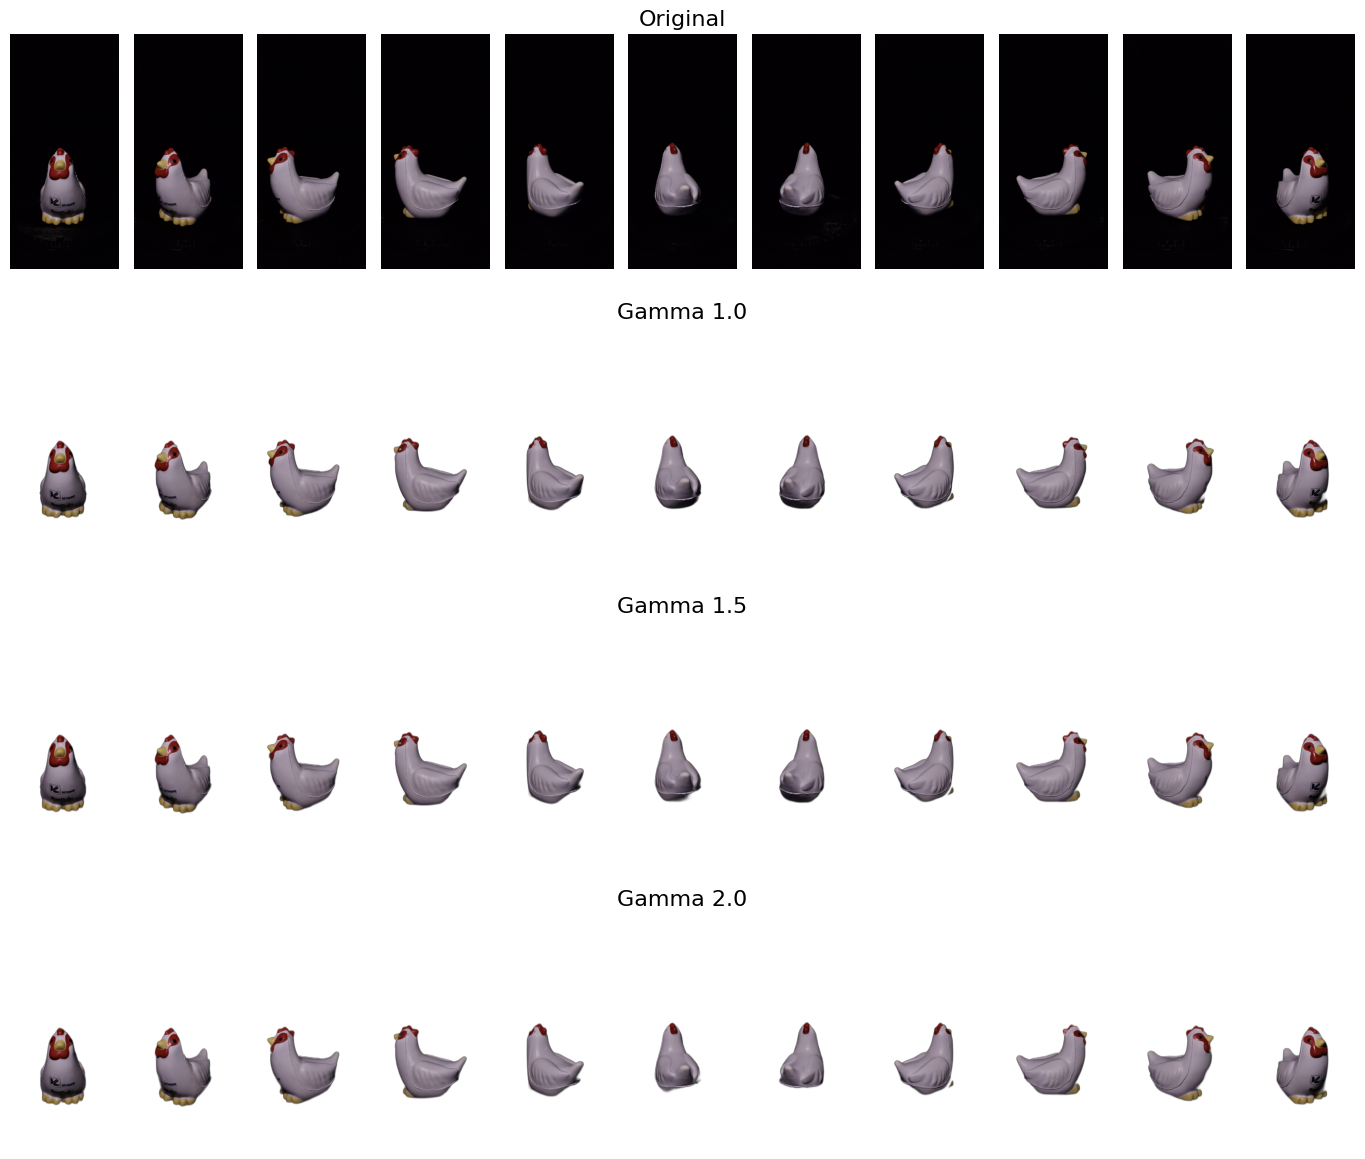

In [21]:
def benchmark_gamma(images, gammas):
    default_rembg_session = rembg.new_session("u2net")

    rows = len(gammas) + 1
    cols = len(images)

    _, axes = plt.subplots(rows, cols, figsize=(1.25 * cols, 3 * rows))
    for i, img_rgb in enumerate(images):
        axes[0, i].imshow(img_rgb)
        axes[0, i].axis('off')
        
        if i == len(images) // 2:
            axes[0, i].set_title("Original", fontsize=16)

        for j, g in enumerate(gammas):
            img_no_bg = remove_background(img_rgb, default_rembg_session, gamma=g)
            
            axes[j+1, i].imshow(img_no_bg)
            axes[j+1, i].axis('off')
            
            if i == len(images) // 2:
                axes[j+1, i].set_title(f"Gamma {g}", fontsize=16)

    plt.tight_layout()
    plt.show()

gammas = [1.0, 1.5, 2.0]
benchmark_gamma(IMAGES, gammas)

Como se puede observar, el mejor valor de gamma para este conjunto de imágenes es 1.5, ya que proporciona un buen equilibrio entre la eliminación del fondo y la preservación de los detalles del objeto.

In [22]:
GAMMA = 1.5

### 1.2.1 Selección de Modelo de Segmentación

La librería `rembg` permite utilizar diferentes modelos de redes neuronales para la segmentación (ej. `u2net`, `u2netp`, `isnet-general-use`, `sam`).

Aunque el modelo por defecto (`u2net`) ofrece un excelente equilibrio entre calidad y rendimiento para objetos generales, en casos donde el objeto tiene detalles muy finos (como cabello o mallas) o un contraste muy bajo con el fondo, sería recomendable realizar un segundo benchmark comparando estos modelos.

Para este proyecto, tras la evaluación visual del benchmark de gamma, determinamos que **`u2net` con Gamma=2.0** proporciona resultados satisfactorios, por lo que procedemos con esta configuración.

Iniciando benchmark de modelos con Gamma=1.5...

Benchmark finalizado.


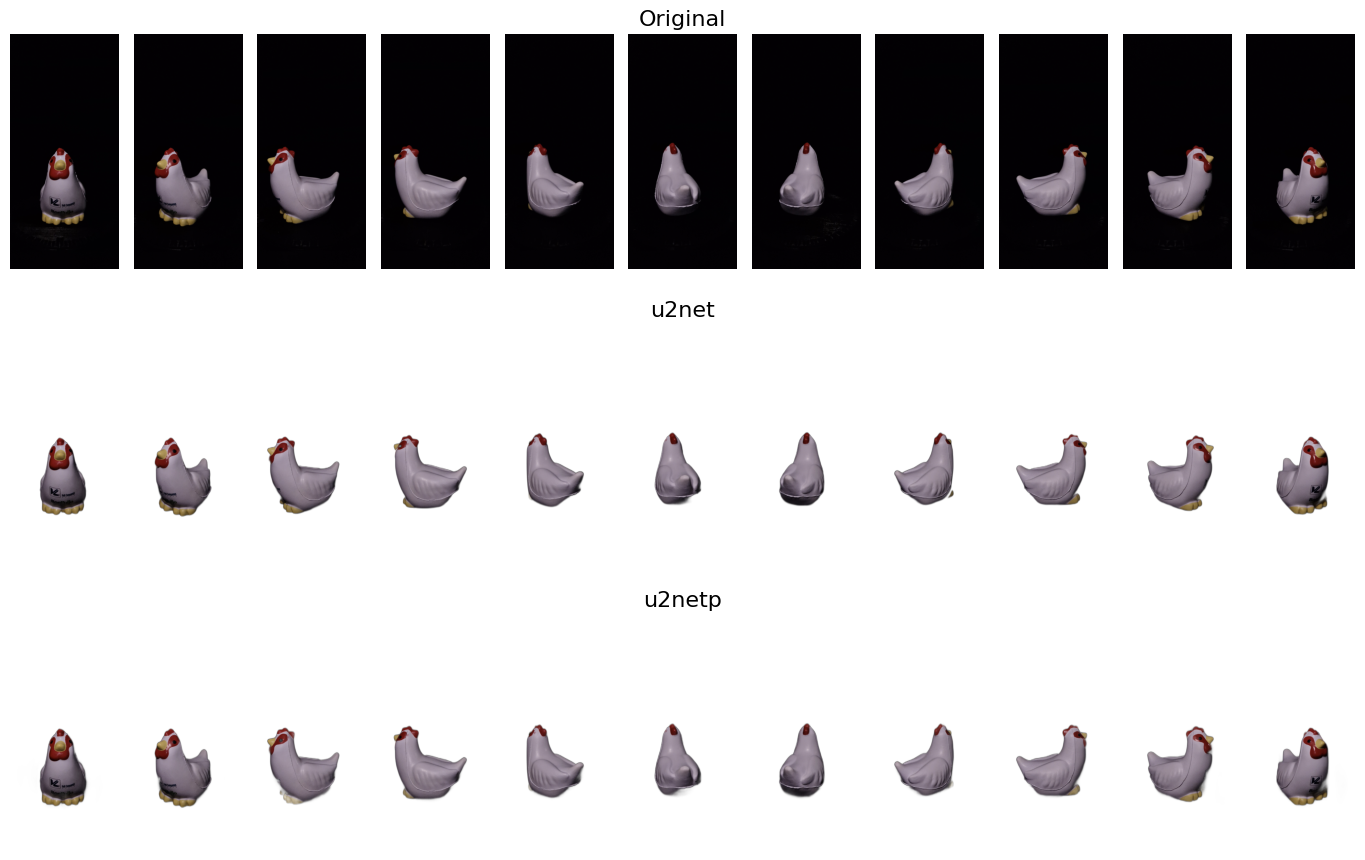

In [23]:
def benchmark_rembg_models(images, gamma):
    model_names = [
        "u2net", "u2netp", #"u2net_human_seg", "u2net_cloth_seg", 
        #"silueta", "isnet-general-use", "isnet-anime"
    ]
    print(f"Iniciando benchmark de modelos con Gamma={gamma}...")
    
    # Pre-cargamos sesiones para evitar recrearlas en el bucle interno
    sessions = {name: rembg.new_session(name) for name in model_names}
    
    rows = len(model_names) + 1
    cols = len(images)

    _, axes = plt.subplots(rows, cols, figsize=(1.25 * cols, 3 * rows))
    
    for i, img in enumerate(images):
        # 1. Original
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == len(images) // 2:
            axes[0, i].set_title("Original", fontsize=16)

        # 2. Modelos
        for j, name in enumerate(model_names):
            # Usamos la sesión pre-cargada y nuestra función remove_background
            res = remove_background(img, sessions[name], gamma=gamma)
            
            axes[j+1, i].imshow(res)
            axes[j+1, i].axis('off')
            
            if i == len(images) // 2:
                axes[j+1, i].set_title(name, fontsize=16)

    print("\nBenchmark finalizado.")
    plt.tight_layout()
    plt.show()

# Ejecución
benchmark_rembg_models(IMAGES, GAMMA)

In [24]:
REMBG_SESSION = rembg.new_session("u2net")

Como vemos en los resultados, el modelo "u2net" con un ajuste de gamma de 1.5 ofrece un equilibrio óptimo entre la precisión del recorte y la preservación de detalles importantes en las imágenes de nuestro objeto de interés.

## 1.3 Ejecución del Pipeline de Preprocesado

Con los parámetros definidos (**Gamma = 1.5**), ejecutamos el procesamiento por lotes para todo el dataset.

El script iterará sobre todas las imágenes cargadas:
1.  Aplicará la eliminación de fondo con la configuración óptima.
2.  Convertirá el resultado al espacio de color BGRA (requerido por OpenCV para guardar).
3.  Guardará los archivos `.png` resultantes en el directorio de salida (`01_state` o similar), listos para la extracción de características.

In [25]:
IMAGES_BGLESS = []
SAMPLE_STATE_01  = os.path.join(SAMPLE_BASE_PATH, '01_state')

print("Iniciando procesamiento...")
for i, img_rgba in enumerate(IMAGES):
    final_img = remove_background(img_rgba, REMBG_SESSION, gamma=GAMMA)
    IMAGES_BGLESS.append(final_img)
    
    filename = f"{i+1:02d}_model.png"
    out_path = os.path.join(SAMPLE_STATE_01, filename)
    cv.imwrite(out_path, final_img)
    # Usamos end='\r' para sobrescribir la línea y evitar imprimir una lista larga
    print(f"|-> Procesada imagen: {filename}", end='\r')

print("") # Salto de línea final
print('Procesamiento completado.')

Iniciando procesamiento...
|-> Procesada imagen: 11_model.png
Procesamiento completado.


# 2. Extracción y detección de características

## 2.1 Algoritmo SIFT (Scale-Invariant Feature Transform)

Para la reconstrucción 3D, es fundamental encontrar puntos correspondientes ("matches") entre pares de imágenes consecutivas. Para ello, utilizamos el algoritmo **SIFT**, un estándar en visión por computador valorado por su gran robustez.

**¿Por qué usamos SIFT?**
A diferencia de otros detectores de esquinas simples, SIFT es capaz de detectar y describir características locales ("keypoints") que son invariantes a:
*   **Escala**: Reconoce el mismo detalle aunque el objeto esté más cerca o más lejos en la foto.
*   **Rotación**: Funciona correctamente aunque la cámara o el objeto hayan girado.
*   **Iluminación**: Es parcialmente invariante a cambios de luz y ruido.

**El flujo de trabajo implementado es:**

1.  **Detección de Keypoints**: Identificamos puntos de interés distintivos en ambas imágenes.
2.  **Cálculo de Descriptores**: Para cada punto, SIFT genera una "huella digital" numérica (vector de 128 valores) que describe la textura y gradientes a su alrededor.
3.  **Matching (Emparejamiento)**: Comparamos los descriptores de la *Imagen A* con los de la *Imagen B*. Utilizamos `BFMatcher` (Brute Force) con `knnMatch` ($k=2$) para encontrar los **dos** mejores candidatos para cada punto.
4.  **Filtrado (Lowe's Ratio Test)**: Para descartar falsos positivos, aplicamos la "Prueba de Razón de Lowe". Solo aceptamos un emparejamiento si la distancia al *mejor* candidato es significativamente menor (por ejemplo, $< 0.7$) que la distancia al *segundo mejor*. Esto elimina ambigüedades y asegura que el match es único y confiable.

# TODO: Mejorar preprocesado previo a SIFT

In [26]:
def feature_and_matching(im1, im2):
    """
    Detecta características y realiza el emparejamiento entre dos imágenes.

    Pasos:
    1. Inicializa el detector SIFT (Scale-Invariant Feature Transform).
    2. Detección de Puntos Clave (Keypoints) y Descriptores.
    3. Emparejamiento de Descriptores (Feature Matching) usando Brute-Force Matcher.
    4. Filtrado de Matches con el Test de Ratio de Lowe.
    5. Extracción de Coordenadas de los Puntos Emparejados.

    Args:
        im1 (numpy.ndarray): Primera imagen de entrada.
        im2 (numpy.ndarray): Segunda imagen de entrada.

    Returns:
        tuple:
            - pts1 (numpy.ndarray): Coordenadas de los puntos emparejados en la primera imagen.
            - pts2 (numpy.ndarray): Coordenadas de los puntos emparejados en la segunda imagen.
            - kp1 (tuple): Puntos clave detectados en la primera imagen.
            - kp2 (tuple): Puntos clave detectados en la segunda imagen.
            - good_matches (list): Lista de matches filtrados.
    """
    sift = cv.SIFT_create()

    kp1, des1 = sift.detectAndCompute(im1, None)
    kp2, des2 = sift.detectAndCompute(im2, None)

    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    
    good_matches = []
    ratio_threshold = 0.7
    for m, n in matches:
        if m.distance < n.distance * ratio_threshold:
            good_matches.append(m)

    pts1 = np.float32([kp1[p.queryIdx].pt for p in good_matches])
    pts2 = np.float32([kp2[p.trainIdx].pt for p in good_matches])

    return pts1, pts2, kp1, kp2, good_matches

## 2.2 Ejecución y Visualización del Matching

A continuación, probamos la función con dos imágenes consecutivas del dataset procesado. Visualizaremos las líneas que conectan los puntos clave encontrados en ambas imágenes para verificar visualmente la calidad de los emparejamientos. Si las líneas son paralelas y coherentes, el matching es correcto; si hay muchas líneas cruzadas caóticas, el filtrado necesita ajuste.

Generando visualización para 11 pares de imágenes...
Total de matches encontrados: 145


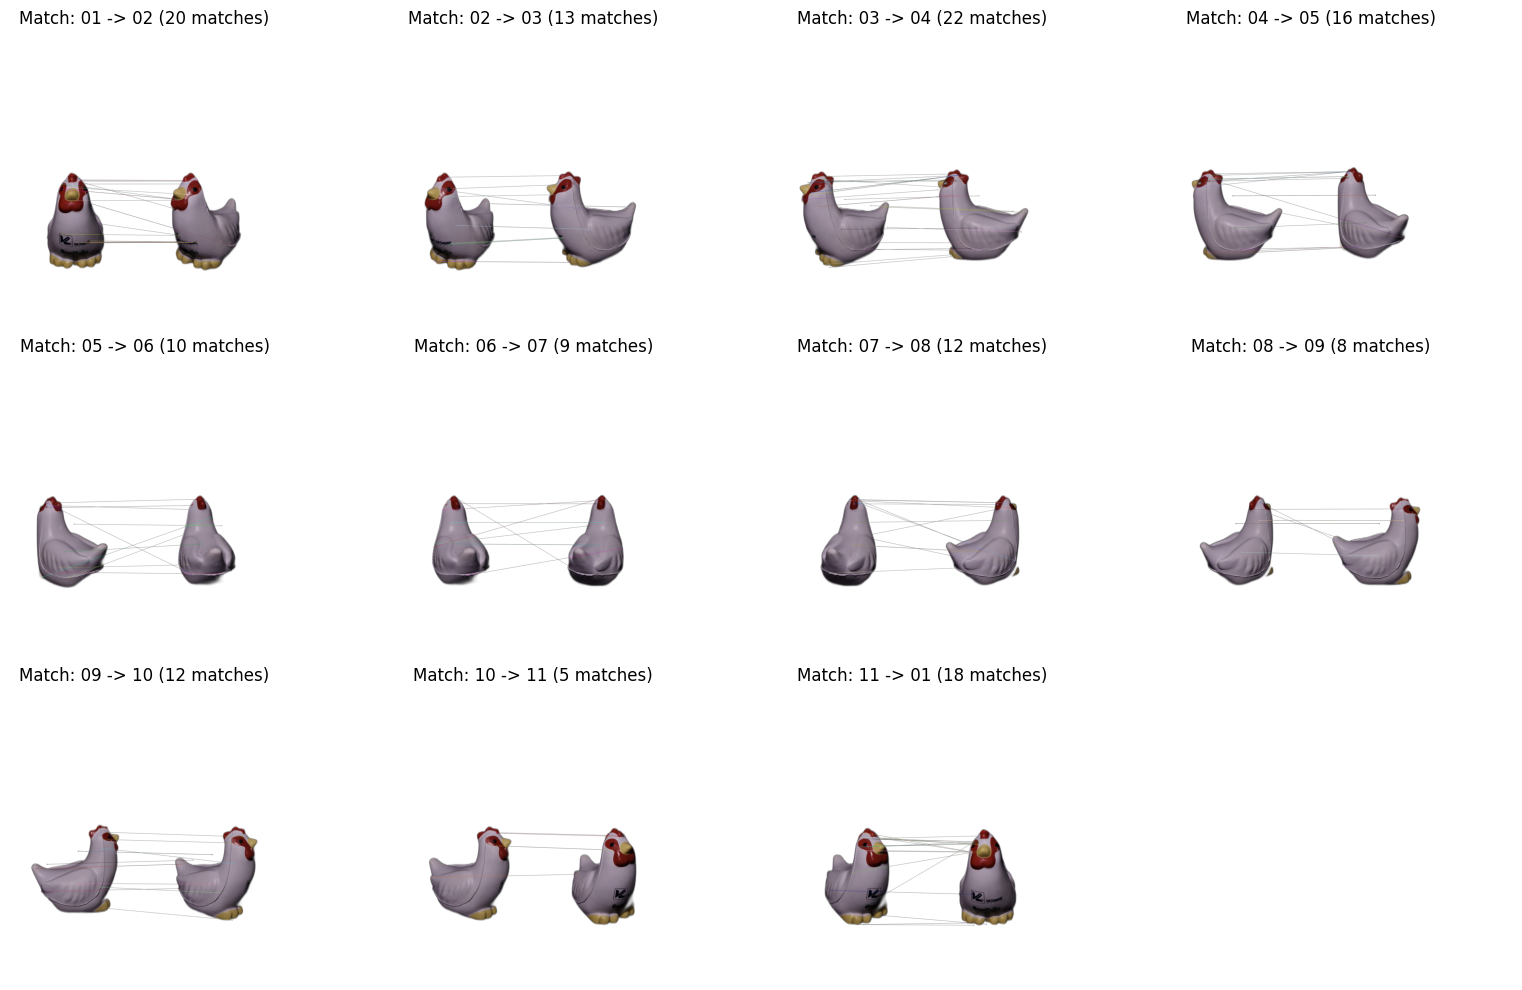

In [27]:
def visualize_matches(images):
    TOTAL_MATCHES = 0

    num_images = len(images)
    pairs = []
    for i in range(num_images):
        pairs.append((i, (i + 1) % num_images))

    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
    axes = axes.flatten()

    print(f"Generando visualización para {len(pairs)} pares de imágenes...")

    for idx, (idx1, idx2) in enumerate(pairs):
        img1 = images[idx1]
        img2 = images[idx2]
        
        # Ejecutamos la función de matching
        pts1, pts2, kp1, kp2, matches = feature_and_matching(img1, img2)
        
        # Dibujamos los matches
        # Usamos flags=2 para dibujar solo los puntos coincidentes y líneas
        res = cv.drawMatches(img1, kp1, img2, kp2, matches, None, flags=2)
        
        ax = axes[idx]
        ax.imshow(res)
        ax.set_title(f"Match: {idx1+1:02d} -> {idx2+1:02d} ({len(matches)} matches)")
        TOTAL_MATCHES += len(matches)
        ax.axis('off')

    # Desactivar ejes sobrantes (si hay)
    for i in range(len(pairs), len(axes)):
        axes[i].axis('off')

    print(f"Total de matches encontrados: {TOTAL_MATCHES}")

    plt.tight_layout()
    plt.show()

visualize_matches(IMAGES_BGLESS)

# TODO: NO ME GUSTA ESTA VISLUALIZACIÓN

## Sfm: Structure from Motion

Buscamos la matriz fundamental utilizando RANSAC y validamos de la Geometría Epipolar para ver si el emparejamiento hecho anteriormente tienen verdaderamente relación geometrica

Generando visualización de epilíneas para 11 pares de imágenes...
No se pudo calcular F para el par 7->8
No hay suficientes puntos para el par 9->10


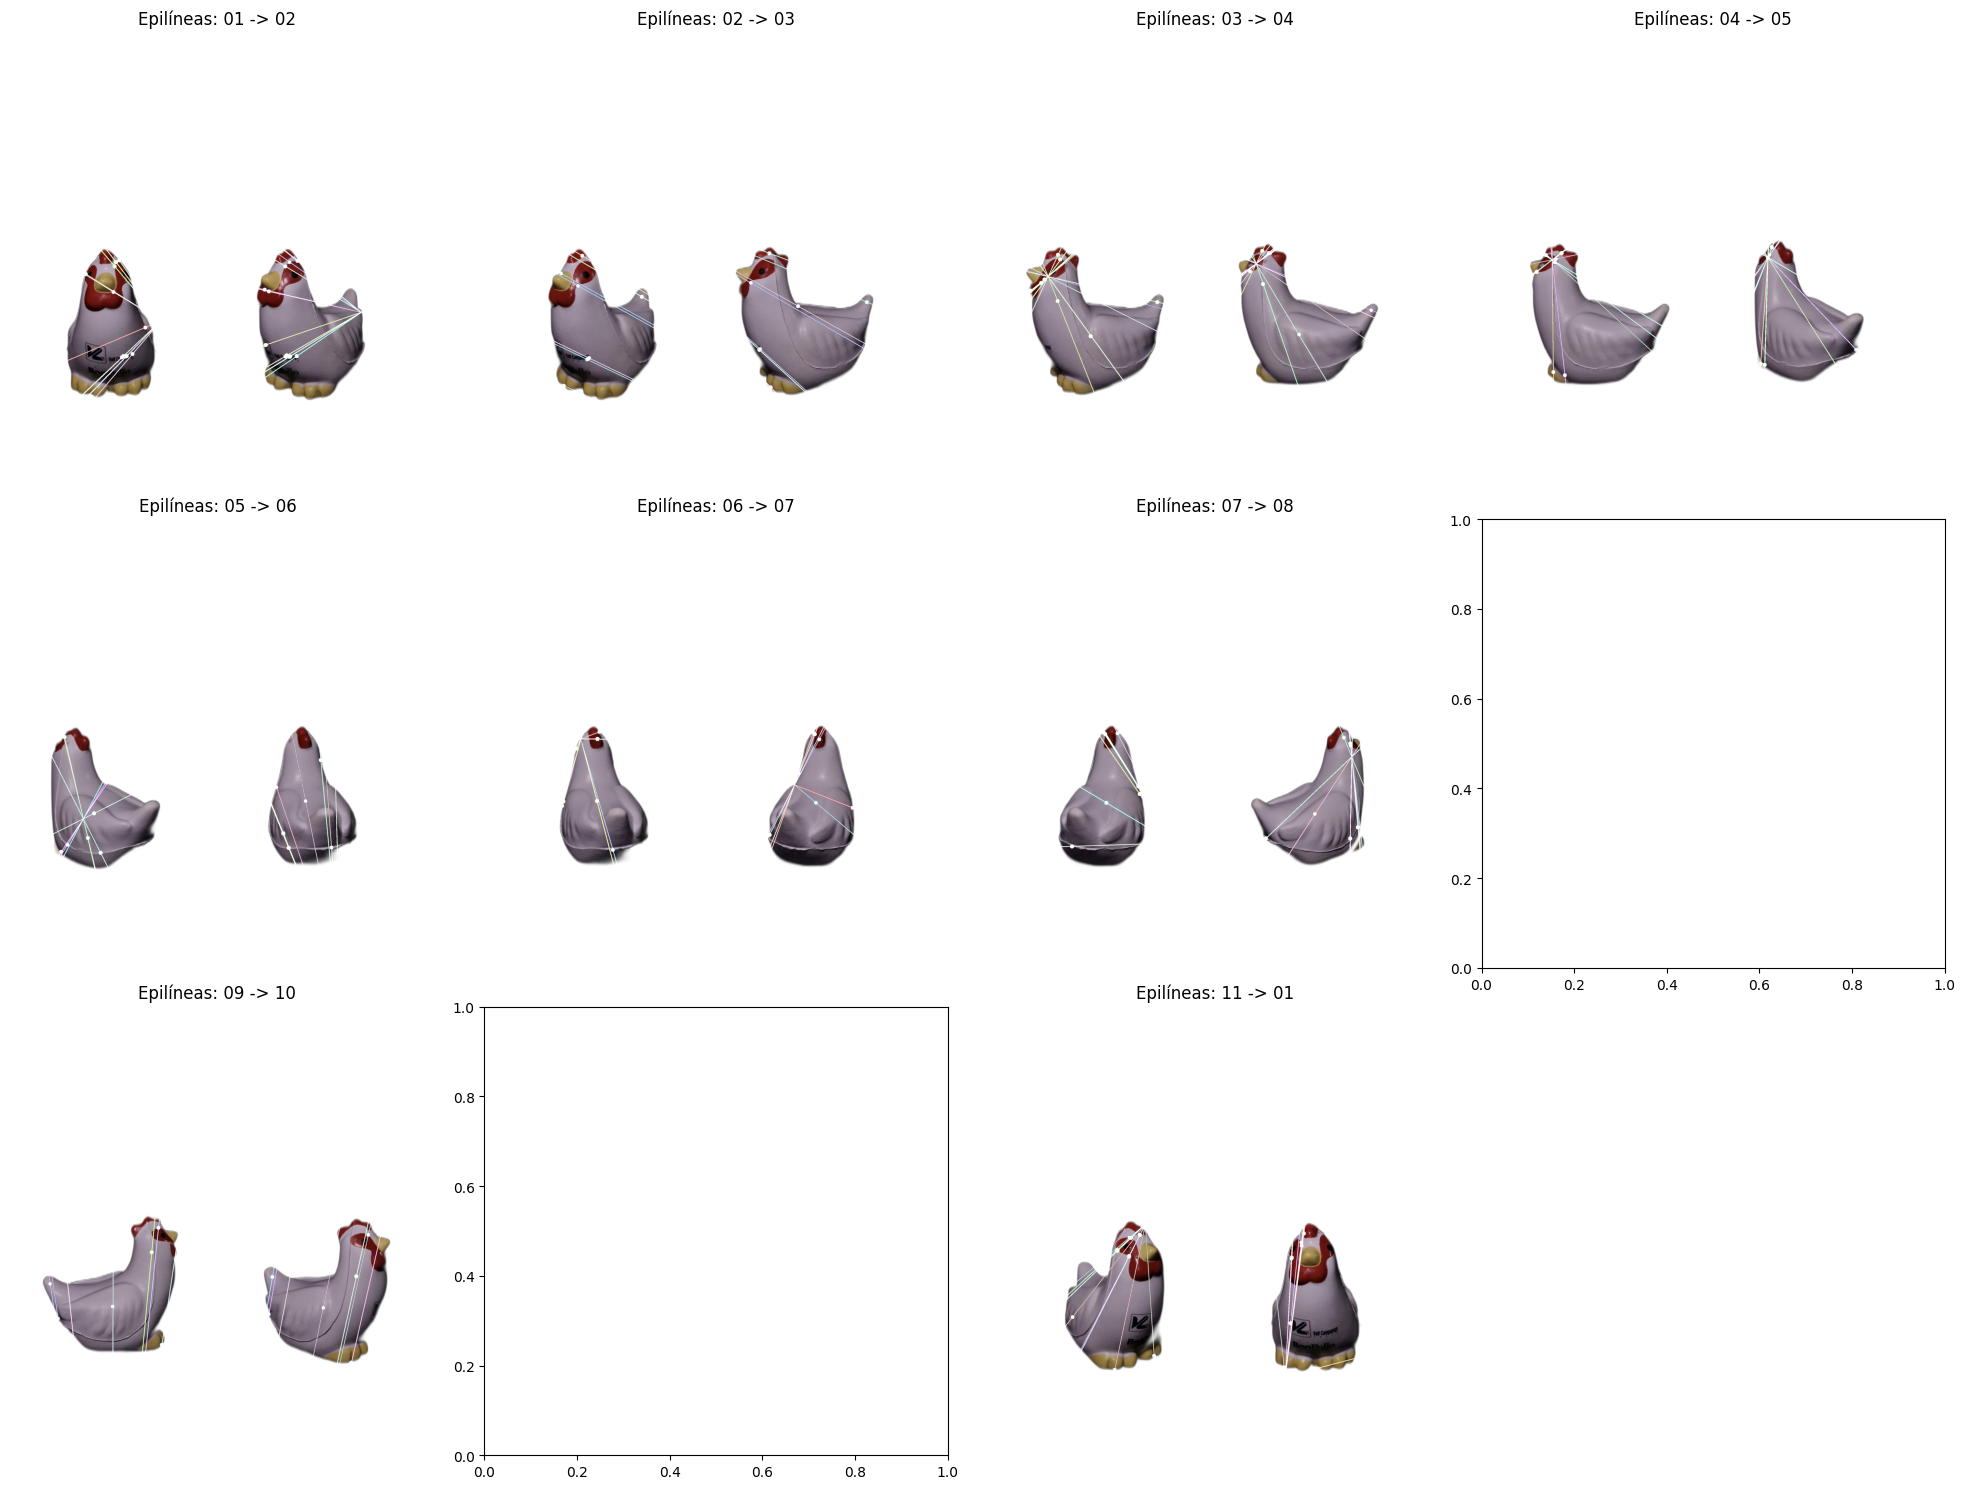

In [28]:
def visualize_epilines_all(images):
    num_images = len(images)
    pairs = []
    for i in range(num_images):
        pairs.append((i, (i + 1) % num_images))

    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
    axes = axes.flatten()

    print(f"Generando visualización de epilíneas para {len(pairs)} pares de imágenes...")

    # Función auxiliar de dibujo (reutilizable)
    def dibujar_epilineas(img, lines, pts):
        h, w = img.shape[:2]
        out_img = img.copy()    
        for r, pt in zip(lines, pts):
            color = tuple(np.random.randint(0, 255, 3).tolist())
            a, b, c = r
            # Dibujar línea: ax + by + c = 0
            # Si b es muy pequeño, es una línea vertical aprox
            if abs(b) > 1e-5:
                y0 = int(-c/b)
                y1 = int(-(c + a*w)/b)
                cv.line(out_img, (0, y0), (w, y1), color, 2)
            else:
                x0 = int(-c/a)
                cv.line(out_img, (x0, 0), (x0, h), color, 2)
                
            # Dibujar el punto (debe caer sobre la línea)
            cv.circle(out_img, tuple(int(x) for x in pt), 10, color, -1)
        return out_img

    for idx, (idx1, idx2) in enumerate(pairs):
        img1 = images[idx1]
        img2 = images[idx2]
        
        # Ejecutamos la función de matching
        pts1, pts2, kp1, kp2, matches = feature_and_matching(img1, img2)

        if len(pts1) < 8:
             print(f"No hay suficientes puntos para el par {idx1}->{idx2}")
             continue

        # 1. Calculamos F y seleccionamos una muestra aleatoria
        F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC)
        
        if F is None:
             print(f"No se pudo calcular F para el par {idx1}->{idx2}")
             continue
        

        # Seleccionamos solo los inliers para que la visualización sea correcta
        mask = mask.ravel() == 1
        pts1_inliers = pts1[mask]
        pts2_inliers = pts2[mask]
        
        if len(pts1_inliers) < 1:
             print(f"No hay inliers para el par {idx1}->{idx2}")
             continue

        # Tomamos 10 índices al azar de los INLIERS
        sample_size = min(10, len(pts1_inliers))
        indices = random.sample(range(len(pts1_inliers)), sample_size)
        p1_sample = pts1_inliers[indices]
        p2_sample = pts2_inliers[indices]

        # 2. Cálculo de líneas recíprocas
        # Líneas en Img1 (correspondientes a puntos de Img2) -> whichImage=2
        lines1 = cv.computeCorrespondEpilines(pts2_inliers.reshape(-1, 1, 2), 2, F).reshape(-1, 3)
        # Líneas en Img2 (correspondientes a puntos de Img1) -> whichImage=1
        lines2 = cv.computeCorrespondEpilines(pts1_inliers.reshape(-1, 1, 2), 1, F).reshape(-1, 3)

        # 4. Visualización Recíproca
        img1_epilines = dibujar_epilineas(img1, lines1, pts1_inliers) # Puntos en Img1 vs Líneas de Img2
        img2_epilines = dibujar_epilineas(img2, lines2, pts2_inliers) # Puntos en Img2 vs Líneas de Img1

        # Mostrar lado a lado
        final_concat = np.hstack((img1_epilines, img2_epilines))
        
        ax = axes[idx]
        ax.imshow(final_concat)
        ax.set_title(f"Epilíneas: {idx1+1:02d} -> {idx2+1:02d}")
        ax.axis('off')

    # Desactivar ejes sobrantes (si hay)
    for i in range(len(pairs), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_epilines_all(IMAGES_BGLESS)

Funcion donde se tiangula las posiciones de los puntos de 2 imagenes para calcular las posiciones 3D de dichas imagenes.

In [29]:
def Sfm(im1, im2, K, R1=np.eye(3), t1=np.zeros((3, 1))):
    """
    Realiza la reconstrucción 3D a partir de dos vistas (Structure from Motion).

    Pasos:
    1. Obtener Puntos Emparejados (SIFT + Matching).
    2. Estimación de la Matriz Esencial (E) y Filtro RANSAC.
    3. Recuperación de la Pose (R, t).
    4. Definición de las Matrices de Proyección (P1 y P2).
    5. Triangulación 3D.
    6. Conversión a Coordenadas Homogéneas.

    Args:
        im1 (numpy.ndarray): Primera imagen.
        im2 (numpy.ndarray): Segunda imagen.
        K (numpy.ndarray): Matriz intrínseca de la cámara.
        R1 (numpy.ndarray, optional): Matriz de rotación de la primera cámara. Defaults to np.eye(3).
        t1 (numpy.ndarray, optional): Vector de traslación de la primera cámara. Defaults to np.zeros((3, 1)).

    Returns:
        tuple:
            - pts3d (numpy.ndarray): Puntos 3D reconstruidos.
            - R2 (numpy.ndarray): Matriz de rotación de la segunda cámara.
            - t2 (numpy.ndarray): Vector de traslación de la segunda cámara.
    """
    pts1, pts2, kp1, kp2, good_matches = feature_and_matching(im1, im2)

    if len(pts1) < 5:
        print(f"Advertencia: No hay suficientes puntos para calcular la matriz esencial ({len(pts1)} puntos).")
        return np.zeros((0, 3)), R1, t1

    E, mask = cv.findEssentialMat(pts1, pts2, K, method=cv.RANSAC, prob=0.99, threshold=1.0)

    if E is None or E.shape != (3, 3):
        print("Advertencia: No se pudo calcular una Matriz Esencial válida.")
        return np.zeros((0, 3)), R1, t1

    # Fix for OpenCV error: The matrix is not continuous
    pts1 = np.ascontiguousarray(pts1)
    pts2 = np.ascontiguousarray(pts2)
    E = np.ascontiguousarray(E)

    try:
        _, R2, t2, pose_mask = cv.recoverPose(E, pts1, pts2, K)
    except cv.error as e:
        print(f"Error en recoverPose: {e}")
        return np.zeros((0, 3)), R1, t1

    mask_final = mask.ravel() & pose_mask.ravel()
    pts1 = pts1[mask_final]
    pts2 = pts2[mask_final]
    
    if len(pts1) == 0:
        print("Advertencia: No quedaron puntos tras recoverPose.")
        return np.zeros((0, 3)), R1, t1

    P1 = np.hstack((R1, t1)) # P1 = K * [I | 0]
    P1 = K @ P1
    t2 = t2 + R1 @ t1
    # La segunda cámara (P2) tiene la pose relativa R y t.
    R2 = R1 @ R2

    P2 = np.hstack((R2, t2)) # P2 = K * [R | t]
    P2 = K @ P2
    
    pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)

    pts3d = pts4d[:3] / pts4d[3]

    return pts3d.T.copy(), R2, t2

In [30]:
def Sfm_rad_y_n(im1, im2, K, rad, n_imgs,  R1=np.eye(3), t1=np.zeros((3, 1))):
    """
    Realiza la reconstrucción 3D a partir de dos vistas usando POSE UNIFORME FIJA.
    
    Args:
        im1, im2: Imágenes.
        K: Matriz intrínseca.
        rad (float): El radio (escala) para el vector de traslación.
        n_imgs (int): Número total de imágenes en la secuencia (para cálculo de ángulo).
        R1, t1: Pose ABSOLUTA de la primera cámara (OPCIONAL).
    """
    
    # 1. Obtener Puntos Emparejados (Necesario para la triangulación)
    pts1, pts2, kp1, kp2, good_matches = feature_and_matching(im1, im2)

    if len(pts1) < 5:
        print(f"Advertencia: No hay suficientes puntos para triangulación ({len(pts1)}).")
        return np.zeros((0, 3)), R1, t1
    
    # Asegurar la contigüidad para OpenCV
    pts1 = np.ascontiguousarray(pts1)
    pts2 = np.ascontiguousarray(pts2)

    # --- 2. CÁLCULO DE LA POSE RELATIVA IDEAL (Sustituye a recoverPose) ---
    
    N = 11  # Número de pasos
    theta = 2 * np.pi / n_imgs # Ángulo uniforme (en radianes)

    # Rotación RELATIVA (R_rel): Rotación uniforme sobre el eje Y
    R_rel = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])
    
    # Traslación RELATIVA (t_rel): Vector de traslación a escala 'rad'
    # T = (-R sin(theta), 0, R (1 - cos(theta)))
    t_rel = np.array([
        [-rad * np.sin(theta)],
        [0],
        [rad * (1 - np.cos(theta))]
    ])

    # --- 3. COMPOSICIÓN DE POSE ABSOLUTA ---
    
    # Pose Absoluta de C1 (Recibida como entrada)
    P1 = K @ np.hstack((R1, t1))

    # Pose Absoluta de C2
    R2 = R1 @ R_rel
    t2 = t_rel + R1 @ t1 

    P2 = K @ np.hstack((R2, t2))
    
    # 4. Triangulación 3D
    # Triangulamos con las poses ABSOLUTAS P1 y P2
    pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)

    # 5. Conversión a Coordenadas 3D (Normalización por W)
    pts3d = pts4d[:3] / pts4d[3]

    return pts3d.T.copy(), R2, t2

In [31]:
# --- PARÁMETROS DE CONFIGURACIÓN ---
# Parámetros del poco x5 pro
# FOCAL_LENGTH = 1200
# PIXEL_SIZE = 0.112

#Parámetros del s22, no tengo ni idea si 
# estos datos estan bien, es todo incoherente
FOCAL_LENGTH = 5.4 
PIXEL_SIZE = 0.00555

P_LOW = 10   # Percentil inferior para filtrado
P_HIGH = 90  # Percentil superior para filtrado

# Cálculo de la matriz intrínseca K
# Asumimos que todas las imágenes tienen el mismo tamaño
if len(IMAGES_BGLESS) > 0:
    h, w = IMAGES_BGLESS[0].shape[:2]
    fx = FOCAL_LENGTH / PIXEL_SIZE
    fy = FOCAL_LENGTH / PIXEL_SIZE
    cx, cy = w / 2, h / 2

    K = np.array([
        [fx, 0, cx],
        [0, fy, cy],
        [0, 0, 1]
    ])
    print("Matriz K calculada.")
else:
    print("Error: No hay imágenes en IMAGES_BGLESS")

Matriz K calculada.


In [32]:
def procesar_reconstruccion_sfm(images, K, p_low=10, p_high=90):
    """
    Ejecuta el pipeline completo de Structure from Motion (SfM) para una secuencia de imágenes.

    Pasos:
    1. Inicialización: Se procesa el primer par de imágenes (0 y 1) para obtener la nube de puntos inicial y la pose relativa.
    2. Reconstrucción Incremental: Se itera sobre el resto de imágenes, calculando la SfM entre pares consecutivos (i-1, i) y acumulando los nuevos puntos 3D.
    3. Filtrado de Validez: Se eliminan puntos con coordenadas infinitas o NaN.
    4. Filtrado de Outliers: Se aplica un filtro basado en percentiles (p_low, p_high) en los ejes X, Y y Z para eliminar ruido y puntos lejanos.

    Args:
        images (list[numpy.ndarray]): Lista de imágenes (arrays) ordenadas secuencialmente.
        K (numpy.ndarray): Matriz intrínseca de la cámara (3x3).
        p_low (int, optional): Percentil inferior para el filtrado de outliers (0-100). Por defecto 10.
        p_high (int, optional): Percentil superior para el filtrado de outliers (0-100). Por defecto 90.

    Returns:
        numpy.ndarray: Array de puntos 3D filtrados de forma (N, 3), donde N es el número de puntos.
                       Devuelve un array vacío si no se generan puntos válidos.
    """
    print(f"--- INICIO DE RECONSTRUCCIÓN SFM ---")
    
    puntos_3d = np.zeros((0, 3))
    R = np.eye(3)
    t = np.zeros((3, 1))
    for i in range(len(images)):
        img1 = images[i]
        img2 = images[(i+1)% len(images)]
        
        #puntos, R, t = Sfm(img1, img2, K, R, t)
        puntos, R, t = Sfm_rad_y_n(img1, img2, K, rad=0.1, n_imgs=len(images))
        
        if len(puntos) > 0:
            puntos_3d = np.vstack((puntos_3d, puntos))
            
        print(f"|-> Añadida imagen {i} (vs {i-1}): +{len(puntos)} puntos", end='\r')
    
    print(f"\nTotal puntos generados (bruto): {len(puntos_3d)}")

    print(f"--- FILTRADO DE PUNTOS ---")

    mascara_validos = np.isfinite(puntos_3d).any(axis=1)
    puntos_limpios = puntos_3d[mascara_validos]
    print(f"Puntos tras eliminar Inf/NaN: {len(puntos_limpios)}")

    if len(puntos_limpios) > 0:
        min_x, max_x = np.percentile(puntos_limpios[:, 0], [p_low, p_high])
        min_y, max_y = np.percentile(puntos_limpios[:, 1], [p_low, p_high])
        min_z, max_z = np.percentile(puntos_limpios[:, 2], [p_low, p_high])

        filtro_percentil = (
            (puntos_limpios[:, 0] > min_x) & (puntos_limpios[:, 0] < max_x) &
            (puntos_limpios[:, 1] > min_y) & (puntos_limpios[:, 1] < max_y) &
            (puntos_limpios[:, 2] > np.max([0,min_z])) & (puntos_limpios[:, 2] < max_z) 
        )

        puntos_finales = puntos_limpios[filtro_percentil]
        
        print(f"Rango Z final: {puntos_finales[:, 2].min():.2f} a {puntos_finales[:, 2].max():.2f}")
        print(f"Puntos finales: {len(puntos_finales)}")
    else:
        puntos_finales = np.array([])
        print("¡Advertencia! No quedaron puntos tras la limpieza básica.")

    print(f"---------------------------------------------------")
    return puntos_finales

# TODO: Aquí pasa algo raro y no no se el que

In [33]:
import plotly.graph_objects as go

# 1. Ejecutar el procesamiento
# Usamos los parámetros definidos anteriormente
puntos_finales = procesar_reconstruccion_sfm(IMAGES, K, p_low=P_LOW, p_high=P_HIGH)

# 2. Visualización
if len(puntos_finales) > 0:
    fig = go.Figure(data=[go.Scatter3d(
        x=puntos_finales[:,0],
        y=puntos_finales[:,1],
        z=puntos_finales[:,2],
        mode='markers',
        marker=dict(
            size=3,
            color=puntos_finales[:,2], # Colorear por profundidad (Z)
            colorscale='Hot',
            opacity=0.8
        )
    )])

    fig.update_layout(
        title=f"Nube de Puntos 3D ({len(puntos_finales)} puntos)",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        margin=dict(l=0, r=0, b=0, t=30)
    )

    fig.show()
    print(puntos_finales)
else:
    print("No hay puntos para visualizar.")

--- INICIO DE RECONSTRUCCIÓN SFM ---
|-> Añadida imagen 10 (vs 9): +18 puntos
Total puntos generados (bruto): 147
--- FILTRADO DE PUNTOS ---
Puntos tras eliminar Inf/NaN: 147
Rango Z final: 0.06 a 0.11
Puntos finales: 74
---------------------------------------------------


[[-8.65442678e-03  3.63492109e-02  7.23528042e-02]
 [-7.29902927e-03  1.01471236e-02  8.66313502e-02]
 [-6.02041837e-04  4.44421060e-02  8.13302398e-02]
 [-8.02368304e-05  1.26010757e-02  6.39730841e-02]
 [ 3.69147019e-04  3.94175947e-03  7.21776858e-02]
 [ 1.45224193e-02  2.97794566e-02  8.34155455e-02]
 [ 1.45344101e-02  2.97871623e-02  8.34326595e-02]
 [ 9.14707896e-04  2.29644263e-03  7.41130486e-02]
 [ 2.18844507e-03  1.73160515e-03  7.78376982e-02]
 [ 2.30547297e-03  1.78003649e-03  7.76982009e-02]
 [ 3.15870997e-03  3.81547697e-02  6.94593638e-02]
 [ 3.70491110e-03  3.77182029e-02  6.96769208e-02]
 [ 4.65831487e-03  3.81891429e-02  7.01230243e-02]
 [ 4.98522818e-03  3.79183106e-02  7.01865703e-02]
 [ 7.22240051e-03  3.78306173e-02  7.14075789e-02]
 [-2.02881563e-02  5.98910265e-03  6.93267509e-02]
 [-2.37033665e-02  2.00900454e-02  1.03583969e-01]
 [-1.21559473e-02  1.06744925e-02  6.56498373e-02]
 [-9.03784204e-03  3.79775576e-02  6.75401464e-02]
 [-8.67274497e-03  3.79072018e-

/home/carlos/Documentos/Informatica/Cuarto año/PID/PID/.venv/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning:

Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.



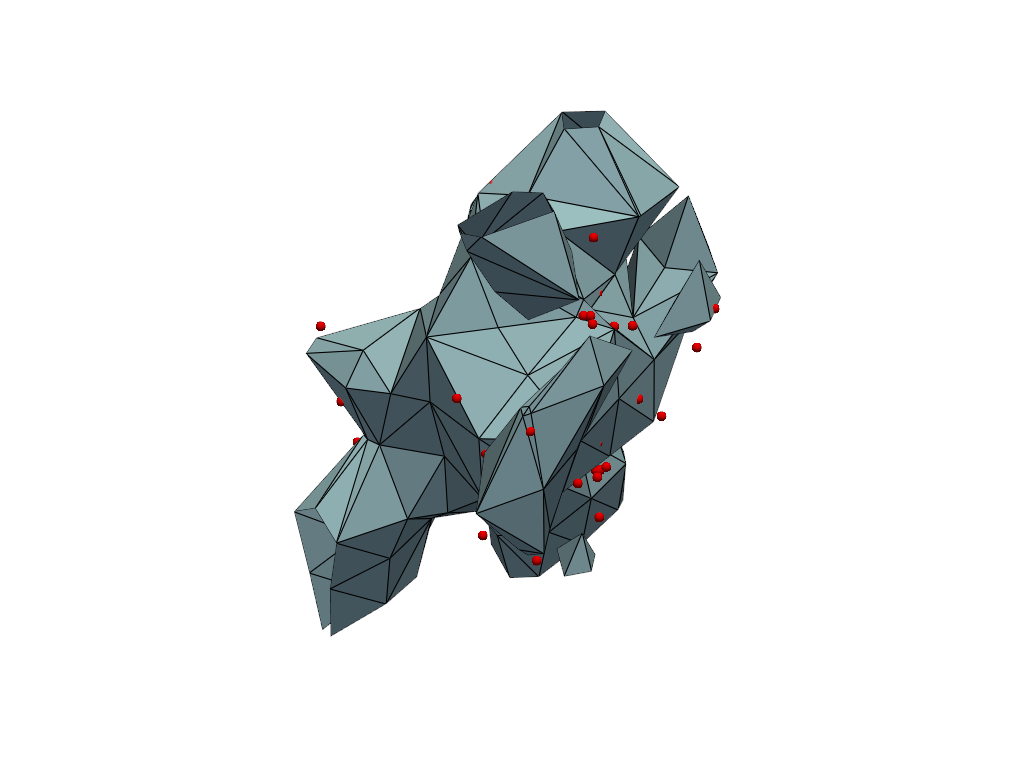

In [34]:
import numpy as np
import pyvista as pv



# --- 2. CONVERTIR NUMPY A OBJETO 3D ---
cloud = pv.PolyData(puntos_finales)

# --- 3. GENERAR LA MALLA (Meshing) ---
# Dado que son puntos dispersos, tenemos dos opciones principales:

# OPCIÓN A: Delaunay 3D (Crea un casco convexo, sólido). 
# Úsalo si tu objeto es compacto y convexo.
# mesh = cloud.delaunay_3d(alpha=0).extract_surface()

# OPCIÓN B: Reconstrucción de Superficie (Similar a Poisson).
# Úsalo si tu objeto es una superficie compleja u orgánica.
# 'nbr_sz' ajusta cuántos puntos vecinos considerar. Juega con esto.
mesh = cloud.reconstruct_surface(nbr_sz=20) 

# --- 4. TEXTURIZADO Y MAPEO UV ---
# Como la malla creada no tiene mapa UV (instrucciones de cómo pegar la imagen),
# tenemos que generar uno automáticamente.

# Si es algo esférico/cilíndrico/orgánico: Mapeo Esférico
mesh.texture_map_to_sphere(inplace=True)

# Si es algo plano (como un terreno o una cara vista de frente): Mapeo Plano
# mesh.texture_map_to_plane(inplace=True) 

# Cargar una textura de prueba (PyVista trae algunas, o usa pv.read_texture('tu_foto.jpg'))
tex = pv.examples.download_masonry_texture()
# Para usar tu propia imagen descomenta abajo:
# tex = pv.read_texture("ruta/a/tu/imagen.jpg")

# --- 5. VISUALIZACIÓN ---
plotter = pv.Plotter()
plotter.add_mesh(mesh, cmap="viridis", show_edges=True) # show_edges ayuda a ver la geometría creada
plotter.add_points(cloud, color="red", point_size=10, render_points_as_spheres=True) # Ver puntos originales
plotter.show()